# Option Pricing Engine Demo

This notebook demonstrates the pricing of European call and put options using:

- Black-Scholes analytical model
- Monte Carlo simulation
- Greeks computation
- Implied volatility estimation

The objective is to validate the numerical methods and compare results across approaches.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from black_scholes import call_price, put_price
from monte_carlo import monte_carlo_call, monte_carlo_put
from greeks import delta_call, gamma, vega, theta_call, rho_call
from implied_vol import implied_vol

## market parameters

In [2]:
S0 = 100      # spot price
K = 105       # strike
T = 1         # maturity in years
r = 0.05      # risk-free rate
sigma = 0.20  # annual volatility

print(f"Spot: {S0}")
print(f"Strike: {K}")
print(f"Maturity: {T} year")
print(f"Rate: {r}")
print(f"Volatility: {sigma}")

Spot: 100
Strike: 105
Maturity: 1 year
Rate: 0.05
Volatility: 0.2


## Black-Scholes Analytical Prices

In [3]:
call_bs = call_price(S0, K, T, r, sigma)
put_bs = put_price(S0, K, T, r, sigma)

print(f"Call Price (BS): {call_bs:.4f}")
print(f"Put Price (BS): {put_bs:.4f}")

Call Price (BS): 8.0214
Put Price (BS): 7.9004


## Monte Carlo Validation
Compare Monte Carlo prices against the analytical Black-Scholes benchmark.

Call Price (MC): 8.0211
Put Price (MC): 7.8851
Call Error: 0.0003
Put Error: 0.0153


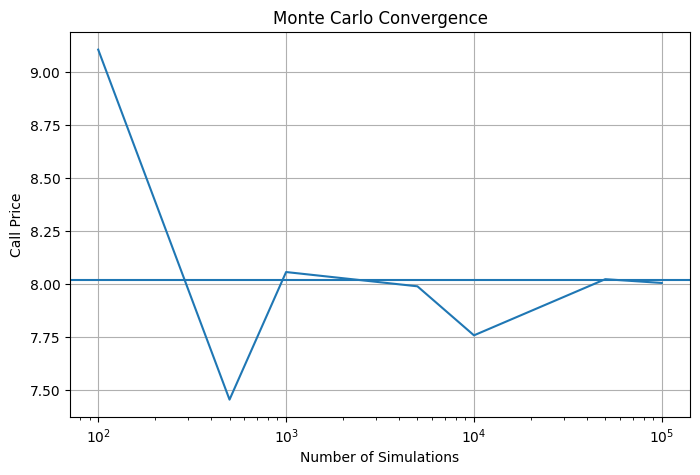

In [4]:
call_mc = monte_carlo_call(S0, K, T, r, sigma)
put_mc = monte_carlo_put(S0, K, T, r, sigma)

print(f"Call Price (MC): {call_mc:.4f}")
print(f"Put Price (MC): {put_mc:.4f}")

print(f"Call Error: {abs(call_bs - call_mc):.4f}")
print(f"Put Error: {abs(put_bs - put_mc):.4f}")

simulations = [100, 500, 1000, 5000, 10000, 50000, 100000]
prices = []

for n in simulations:
    price = monte_carlo_call(S0, K, T, r, sigma, n_sim=n)
    prices.append(price)

plt.figure(figsize=(8,5))
plt.plot(simulations, prices)
plt.axhline(call_bs)
plt.xscale("log")
plt.xlabel("Number of Simulations")
plt.ylabel("Call Price")
plt.title("Monte Carlo Convergence")
plt.grid(True)
plt.show()

## Greek sensivity

In [6]:
spots = np.linspace(50, 180, 300)

deltas = [delta_call(S, K, T, r, sigma) for S in spots]
gammas = [gamma(S, K, T, r, sigma) for S in spots]
vegas = [vega(S, K, T, r, sigma) for S in spots]
thetas = [theta_call(S, K, T, r, sigma) for S in spots]
rhos = [rho_call(S, K, T, r, sigma) for S in spots]

## Delta plot

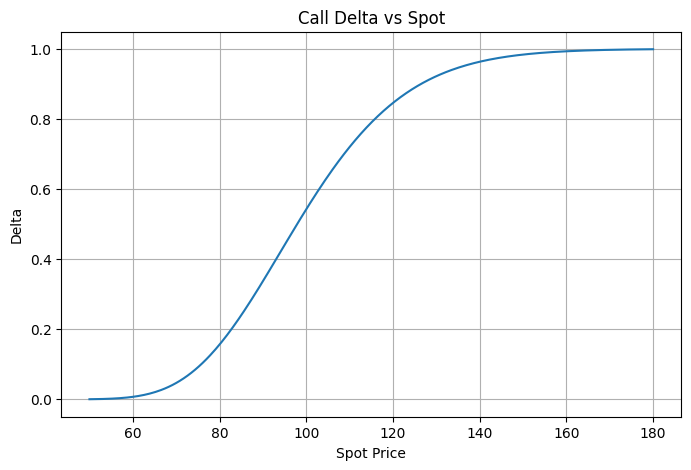

In [7]:
plt.figure(figsize=(8,5))
plt.plot(spots, deltas)
plt.xlabel("Spot Price")
plt.ylabel("Delta")
plt.title("Call Delta vs Spot")
plt.grid(True)
plt.show()

## Gamma plot

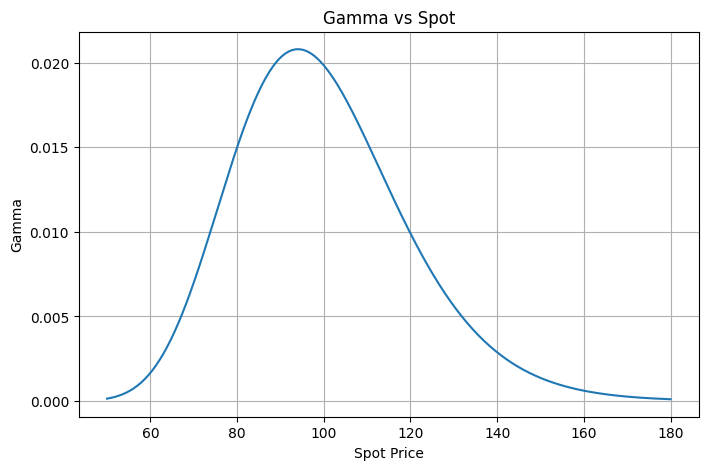

In [8]:
plt.figure(figsize=(8,5))
plt.plot(spots, gammas)
plt.xlabel("Spot Price")
plt.ylabel("Gamma")
plt.title("Gamma vs Spot")
plt.grid(True)
plt.show()

## Vega plot

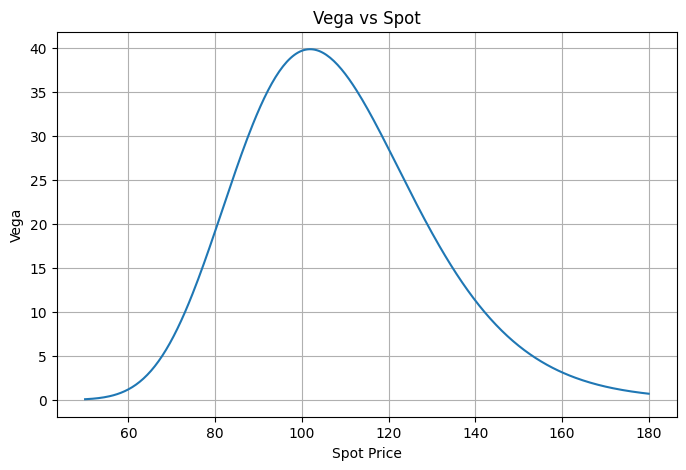

In [9]:
plt.figure(figsize=(8,5))
plt.plot(spots, vegas)
plt.xlabel("Spot Price")
plt.ylabel("Vega")
plt.title("Vega vs Spot")
plt.grid(True)
plt.show()

## Theta plot

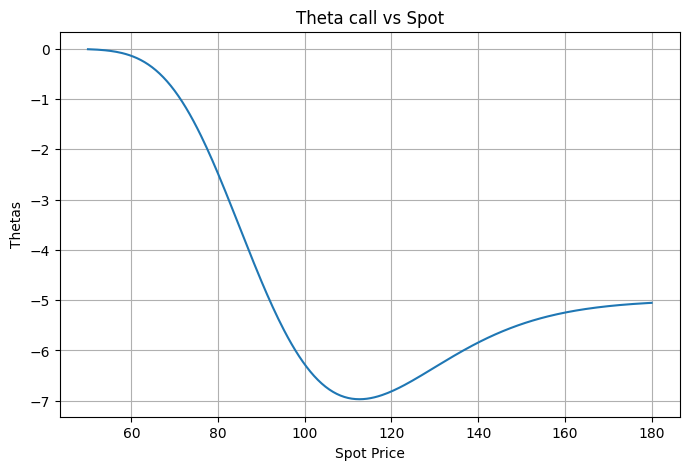

In [10]:
plt.figure(figsize=(8,5))
plt.plot(spots, thetas)
plt.xlabel("Spot Price")
plt.ylabel("Thetas")
plt.title("Theta call vs Spot")
plt.grid(True)
plt.show()

## Rho plot

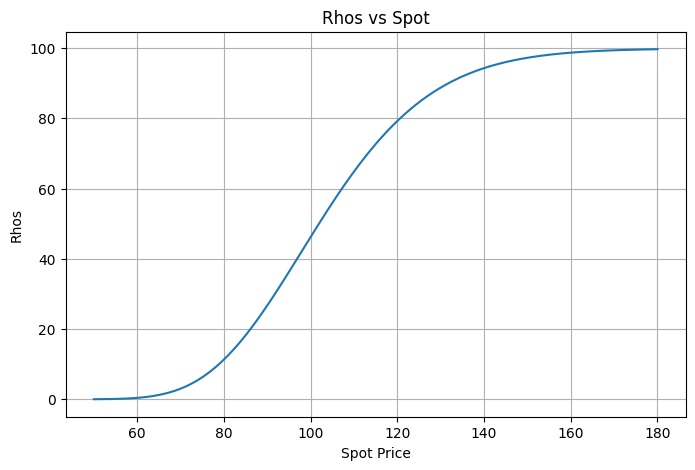

In [11]:
plt.figure(figsize=(8,5))
plt.plot(spots, rhos)
plt.xlabel("Spot Price")
plt.ylabel("Rhos")
plt.title("Rhos vs Spot")
plt.grid(True)
plt.show()

## Price vs volatility 

## Implied Volatility Recovery
Recover the volatility from a synthetic market option price.

In [8]:
market_price = call_bs

iv = implied_vol(market_price, S0, K, T, r)

print(f"Original sigma: {sigma}")
print(f"Recovered IV: {iv:.4f}")

Original sigma: 0.2
Recovered IV: 0.2000


## Volatality smile

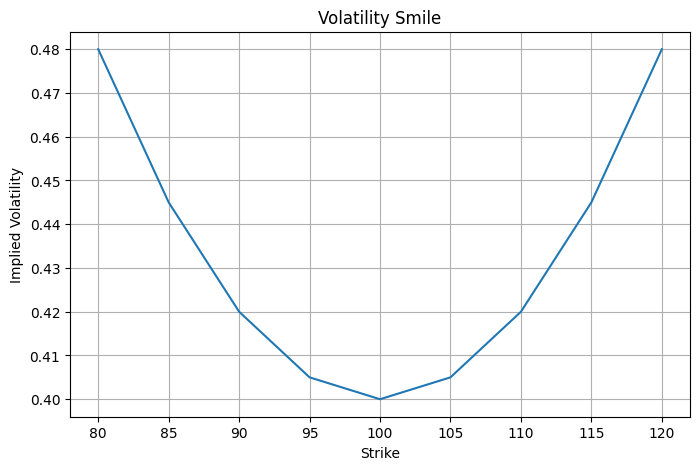

In [16]:
def synthetic_vol(k):
    return 0.2 + 0.0002 * (k - 100)**2

strikes = np.arange(80, 121, 5)
market_prices = [call_price(S0, k, T, r, sigma + synthetic_vol(k)) for k in strikes]

ivs = [implied_vol(price, S0, k, T, r)
       for k, price in zip(strikes, market_prices)]

plt.figure(figsize=(8,5))
plt.plot(strikes, ivs)
plt.xlabel("Strike")
plt.ylabel("Implied Volatility")
plt.title("Volatility Smile")
plt.grid(True)
plt.show()